In [1]:
# General imports
import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import interp1d
from scipy import integrate
from copy import deepcopy

# cloelib imports
from cloelib.cosmology.camb_cosmology import CAMBBackground, CAMBLinearPerturbations, CAMBNonLinearPerturbations
from cloelib.cosmology.class_cosmology import CLASSBackground, CLASSLinearPerturbations, CLASSNonLinearPerturbations
from cloelib.cosmology.HMcode2020Emu_cosmology import HMemuLinearPerturbations, HMemuNonLinearPerturbations
from cloelib.observables.photo import ShearTracer, PositionsTracer
from cloelib.summary_statistics.angular_two_point import AngularTwoPoint
from cloelib.summary_statistics.angular_correlation_function_wigner import AngularCorrelationFunctionWigner

import euclidlib as el

# Plot style
import seaborn as sns
sns.set_theme(style="ticks")
sns.set_palette(sns.color_palette("Paired"))

plt.rc('xtick',labelsize=20)
plt.rc('ytick',labelsize=20)
plt.rc('font',size=20)
plt.rc('axes', titlesize=25)
plt.rc('axes', labelsize=20)
plt.rc('lines', linewidth=3)
plt.rc('lines', markersize=6)
plt.rc('legend', fontsize=14)

/mnt/users/grimmn/miniforge3/envs/cloe-org-env/lib/python3.12/site-packages/HMcode2020Emu
Loading linear emulator...


2026-09-16 13:20:38.660303: E external/local_xla/xla/stream_executor/cuda/cuda_platform.cc:51] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


Linear emulator loaded in memory.
Loading nonlinear emulator...
Non-linear emulator loaded in memory.
Loading linear emulator...
Baryonic boost emulator loaded in memory.
Loading sigma8 emulator...
Linear emulator loaded in memory.


In [2]:
import importlib
# Import Weyl specific classes 
import cloelib.cosmology.Weyl_cosmology as wp

importlib.reload(wp)

from cloelib.cosmology.Weyl_cosmology import WeylNonLinearPerturbations, WeylLinearPerturbations

import cloelib.observables.photo_Weyl as pw


# reload module
importlib.reload(pw)

# re-bind updated classes
PositionsTracer_Weyl_GC = pw.PositionsTracer_Weyl_GC
PositionsTracer_Weyl_GGL = pw.PositionsTracer_Weyl_GGL

In [3]:
import cloelib.cosmology.HMcode2020Emu_cosmology as hm

importlib.reload(hm)

from cloelib.cosmology.HMcode2020Emu_cosmology import (
    HMemuLinearPerturbations,
    HMemuNonLinearPerturbations,
)

Loading linear emulator...
Linear emulator loaded in memory.
Loading nonlinear emulator...
Non-linear emulator loaded in memory.
Loading linear emulator...
Baryonic boost emulator loaded in memory.
Loading sigma8 emulator...
Linear emulator loaded in memory.


In [4]:
import Cells_calculation_Weylproject 

importlib.reload(Cells_calculation_Weylproject)

Cells_calculation = Cells_calculation_Weylproject.Cells_calculation
Cells_calculation_Weyl = Cells_calculation_Weylproject.Cells_calculation_Weyl

## Cosmology: Background and Perturbations

This code snippet initializes and computes the cosmological background and perturbations at various redshifts using the **CAMB** and **HMCode2020Emu** interfaces.

In [5]:
zs = np.linspace(1e-4, 3, 200)
z_ini = 10
camb_background = CAMBBackground(H0=70.0, Omega_cdm0=0.25, Omega_b0=0.05, w0=-1, wa=0, Omega_k0 = 0.0, ns = 0.96, 
                                 As = 2e-9, mnu = 0.06, gamma_MG = 0.545, N_mnu = 1)
#camb_background = CAMBBackground(H0=70.0, Omega_cdm0=0.25, Omega_b0=0.05, w0=-1, wa=0, Omega_k0 = 0.0, ns = 0.96, 
#                                 As = 2e-9, mnu = 0.00, gamma_MG = 0.545, N_mnu = 0) #uncomment this one if you want to have zero neutrinos
linear_perturbations_CAMB = CAMBLinearPerturbations(background=camb_background, redshifts = np.append(zs,z_ini))
nonlinear_perturbations_CAMB = CAMBNonLinearPerturbations(background=camb_background, linearperturbations = linear_perturbations_CAMB, redshifts = np.append(zs,z_ini), 
                                                       nonlinear_model = 'mead2020', log10TAGN=7.8)

Note: redshifts have been re-sorted (earliest first)
Note: redshifts have been re-sorted (earliest first)


In [6]:
class_background = CLASSBackground(H0=70.0, Omega_cdm0=0.25, Omega_b0=0.05, w0=-1, wa=0, Omega_k0 = 0.0, 
                           ns = 0.96, As = 2e-9, mnu = 0.06, gamma_MG = 0.545, N_mnu = 1)
#class_background = CLASSBackground(H0=70.0, Omega_cdm0=0.25, Omega_b0=0.05, w0=-1, wa=0, Omega_k0 = 0.0, 
#                            ns = 0.96, As = 2e-9, mnu = 0.00, gamma_MG = 0.545, N_mnu = 0)
linear_perturbations_CLASS = CLASSLinearPerturbations(background=class_background, redshifts= np.append(zs,z_ini))
nonlinear_perturbations_CLASS = CLASSNonLinearPerturbations(background=class_background,linearperturbations = linear_perturbations_CLASS,  redshifts = np.append(zs,z_ini), 
                                                            nonlinear_model = 'hmcode')

In [7]:
z_ini_test = 4.00
#linear_perturbations_CAMB_zini_test = CAMBLinearPerturbations(background=camb_background, redshifts = np.append(zs, z_ini_test))
#nonlinear_perturbations_CAMB_zini_test = CAMBNonLinearPerturbations(background=camb_background, linearperturbations = linear_perturbations_CAMB, redshifts = np.append(zs, z_ini_test), 
#                                                       nonlinear_model = 'mead2020', log10TAGN=7.8)
linear_perturbations_CLASS_zini_test = CLASSLinearPerturbations(background=class_background, redshifts = np.append(zs, z_ini_test))
nonlinear_perturbations_CLASS_zini_test = CLASSNonLinearPerturbations(background=class_background,linearperturbations = linear_perturbations_CLASS, redshifts = np.append(zs, z_ini_test), 
                                                       nonlinear_model = 'hmcode')

In [8]:
z_ini_emu = 4 # Only works up to z_ini = 4 max using HM emu perturbations

background = CAMBBackground(H0=70.0, 
                            Omega_cdm0=0.25, 
                            Omega_b0=0.05, 
                            w0=-1, 
                            wa=0, 
                            Omega_k0 = 0.0, 
                            ns = 0.96, 
                            As = 2e-9,
                            mnu = 0.06,
                            gamma_MG = 0.545,
                            N_mnu = 1)
linear_perturbations_emu = HMemuLinearPerturbations(background, redshifts= np.append(zs, z_ini_emu))
nonlinear_perturbations_emu = HMemuNonLinearPerturbations(background, linear_perturbations_emu, redshifts= np.append(zs, z_ini_emu))

## Download and Read the Data

In this step, we use the `euclidlib` library to read the data, which follows . `euclidlib` provides the necessary functions and utilities to access and handle data from the Euclid mission, allowing us to seamlessly retrieve, process, and analyze the large datasets generated by the mission. 

For this tutorial, we use example synthetic data stored at https://zenodo.org/communities/cloe-org


In [9]:
# Execute this cell to download the data
data_downloaded = True #Set to False if you have not downloaded it yet

if data_downloaded == False:
    
    import requests
    
    # URLs of the files to be downloaded
    urls = {
        'synthetic_coupled_cells.fits': 'https://zenodo.org/records/17191365/files/example-spectra.fits',
    }
    
    # Function to download a file
    def download_file(url, filename):
        response = requests.get(url)
        if response.status_code == 200:
            with open(filename, 'wb') as f:
                f.write(response.content)
            print(f'{filename} downloaded successfully')
        else:
            print(f'Failed to download {filename}. Status code: {response.status_code}')
    
    # Download all files
    for filename, url in urls.items():
        download_file(url, filename)

In [10]:
# Execute this cell to download the data
data_downloaded = True #Set to False if you have not downloaded it yet

if data_downloaded == False:
    
    import requests
    
    # URLs of the files to be downloaded
    urls = {
        'nz_example.fits': 'https://zenodo.org/records/15092862/files/nz_example.fits',
        'mixmats_example.fits': 'https://zenodo.org/records/17191365/files/example-mixmats.fits',
        'cls_example.fits': 'https://zenodo.org/records/17191365/files/example-spectra.fits'
    }
    
    # Function to download a file
    def download_file(url, filename):
        response = requests.get(url)
        if response.status_code == 200:
            with open(filename, 'wb') as f:
                f.write(response.content)
            print(f'{filename} downloaded successfully')
        else:
            print(f'Failed to download {filename}. Status code: {response.status_code}')
    
    # Download all files
    for filename, url in urls.items():
        download_file(url, filename)

In [11]:
# Read the data using euclidlib v2025.w
# Remember, only pip install euclidlib necessary!
#z_nz, nz_example = el.photo.redshift_distributions('nz_example.fits')
#cls_example = el.photo.angular_power_spectra('cls_example.fits')
#mixmats_example = el.photo.mixing_matrices('mixmats_example.fits')

#If you're using the newer 2026 euclidlib version
z_nz, nz_example = el.phz.redshift_distributions('nz_example.fits')
cls_example = el.le3.pk_wl.angular_power_spectra('cls_example.fits')
mixmats_example = el.le3.pk_wl.mixing_matrices('mixmats_example.fits')

## Plot the galaxy redshift distribution $n(z)$

We use a synthetic galaxy redshift bin distribution that contains 6 redshift bins. We assume that both sources and lenses follow the same distributions.

In [12]:
# Function to normalize dndz
def normalize_dndz(nz_example, z_nz):
    normalized = {}
    for key in nz_example:
        normalized[key] = nz_example[key] / integrate.trapezoid(nz_example[key], z_nz)
    return normalized

# Normalize both dndz_pos and dndz_she
# Note: dndz_pos_norm and 
dndz_pos_norm = normalize_dndz(nz_example, z_nz)
dndz_she_norm = normalize_dndz(nz_example, z_nz)

# Function to resample the normalized dndz
def resample_dndz(nz_example, z_nz, myz):
    my_dndz = np.vstack(list(nz_example.values()))
    my_dndz_norm = np.zeros([len(nz_example), len(myz)])
    for i in range(len(nz_example)):
        my_dndz_norm[i, :] = np.interp(myz, z_nz, my_dndz[i, :])
    return my_dndz_norm

# Resampling the normalized dndz with 100 values
my_dndz_pos_norm = resample_dndz(dndz_pos_norm, z_nz, zs)
my_dndz_she_norm = resample_dndz(dndz_she_norm, z_nz, zs)

In [13]:
# Compute effective redshifts
z_effs = []
for key in dndz_pos_norm.keys():
    n = dndz_pos_norm[key]
    dz = np.gradient(z_nz)
    z_eff = np.sum(z_nz * n * dz) / np.sum(n * dz)
    z_effs.append(z_eff)

z_effs = np.array(z_effs)

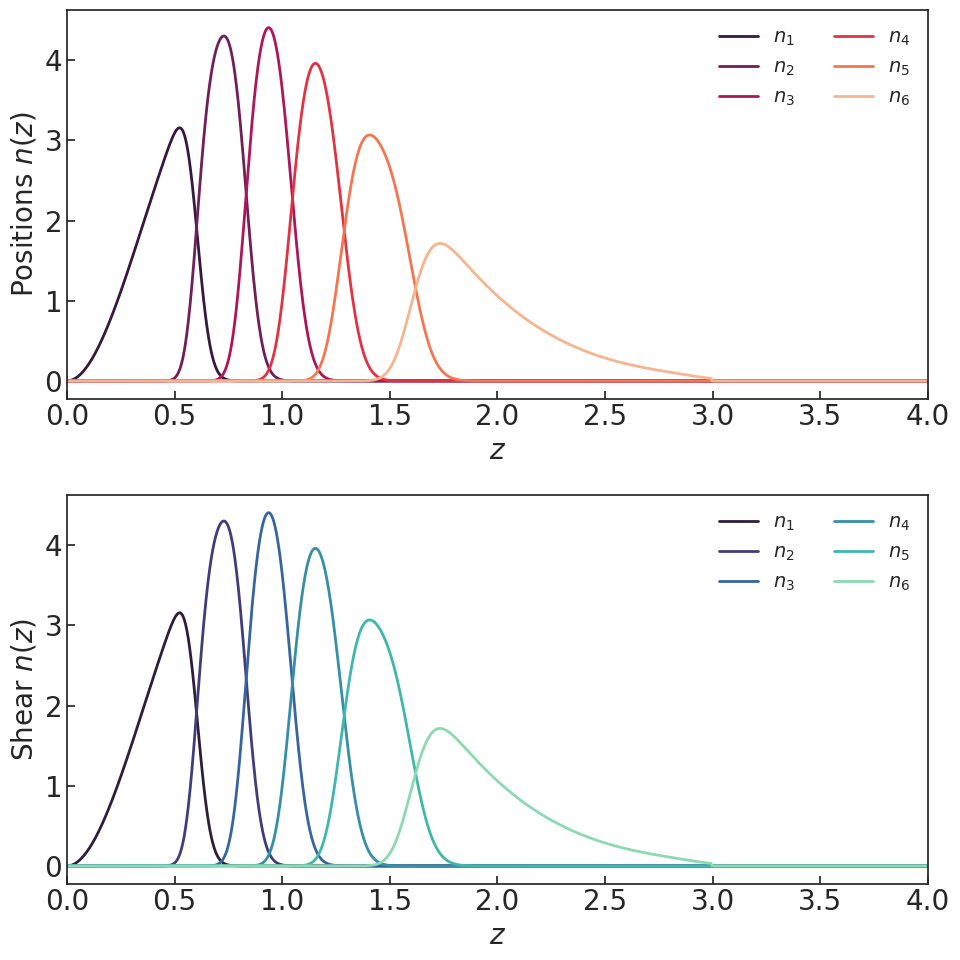

In [14]:
# Plotting dndz
fig, axs = plt.subplots(2, 1, figsize=(10, 10))

# Customize tick parameters for both axes
for ax in axs.flatten():
    ax.tick_params(axis='both', which='both', direction='in')

# Plot positions n(z)
for i, (key, color) in enumerate(zip(dndz_pos_norm.keys(), sns.color_palette("rocket", len(dndz_pos_norm)))):
    axs[0].plot(z_nz, dndz_pos_norm[key], label=f'$n_{{{i+1}}}$', linewidth=2, color=color)

# Plot shear n(z)
for j, (key, color) in enumerate(zip(dndz_she_norm.keys(), sns.color_palette("mako", len(dndz_she_norm)))):
    axs[1].plot(z_nz, dndz_she_norm[key], label=f'$n_{{{j+1}}}$', linewidth=2, color=color)

# Set labels and legends
axs[0].set_xlabel(r'$z$')
axs[0].set_ylabel(r'Positions $n(z)$')
axs[0].set_xlim(0, 4)
axs[0].legend(frameon=False, ncol=2)

axs[1].set_xlabel(r'$z$')
axs[1].set_ylabel(r'Shear $n(z)$')
axs[1].set_xlim(0, 4)
axs[1].legend(frameon=False, ncol=2)

plt.tight_layout()
plt.show()

## Photometric 2x2pt observables: Standard implementation

We compute window functions for galaxy positions observations, as well as the Cells for Galaxy Clustering and Galaxy-Galaxy Lensing. 
We use the standard PositionsTracer class, which will serve as a comparison to the Weyl implementation used in the next section.

### Observables: standard position tracer (standard, CLASS, linear)

In [15]:
Cells_standard = Cells_calculation(linear_perturbations_CLASS, my_dndz_pos_norm, my_dndz_she_norm, zs)
Cells_standard.calculate_Cells()

#### Plots window functions

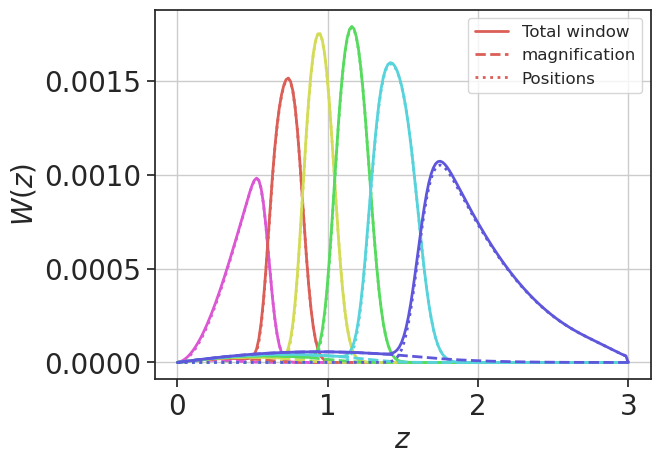

In [16]:
# Plotting the position window functions (magnification, positions, total)
# We do not plot the shear window functions, since we do not need it for any comparison (ShearTracer is used unchanged in the Weyl implementation)
Cells_standard.plot_windows_pos()

#### Plots Cells

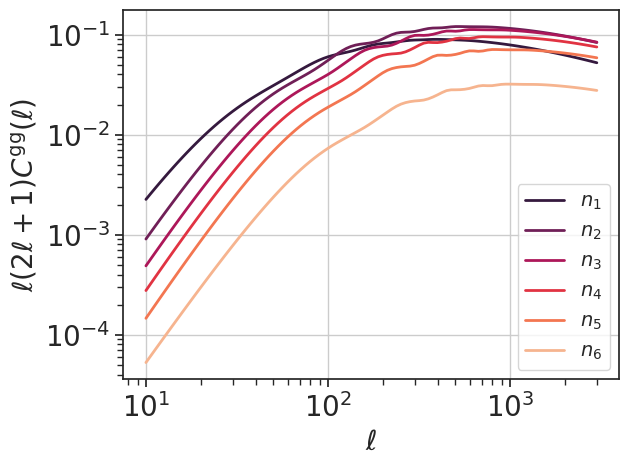

In [17]:
Cells_standard.plot_cells_GC()

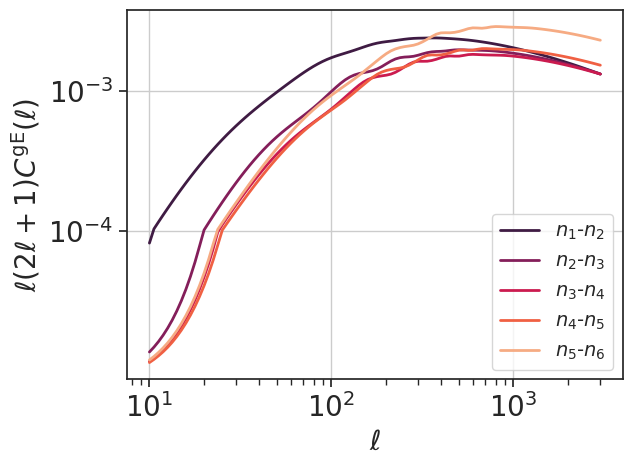

In [51]:
ij_list = [[i,i+1] for i in range(1,6)]
Cells_standard.plot_cells_GGL(ij_list)

### Observables: standard position tracer (standard, CAMB, linear)

In [22]:
Cells_standard_CAMB = Cells_calculation(linear_perturbations_CAMB, my_dndz_pos_norm, my_dndz_she_norm, zs)
Cells_standard_CAMB.calculate_Cells()

#### Plots Cells

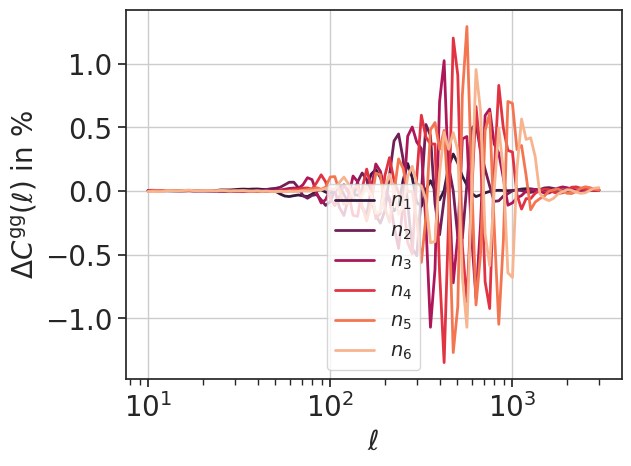

In [23]:
Cells_standard_CAMB.plot_cells_GC_compare(Cells_standard)

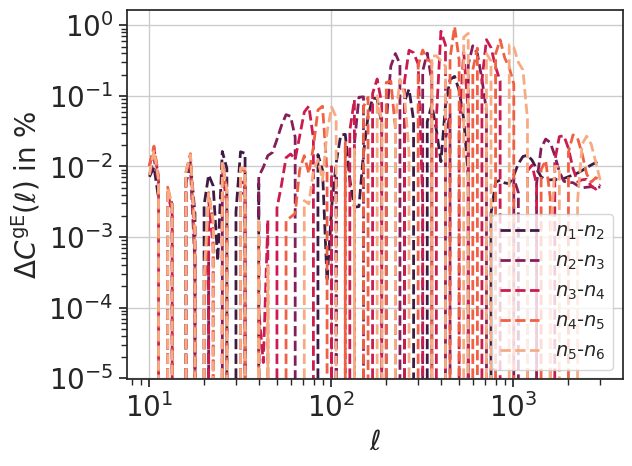

In [24]:
ij_list = [[i,i+1] for i in range(1,6)]
#Cells_standard_CAMB.plot_cells_GGL(ij_list)
Cells_standard_CAMB.plot_cells_GGL_compare(Cells_standard, ij_list, in_percent = True, yscale = 'log')

### Observables: standard position tracer (standard, CLASS, non-linear)

In [25]:
Cells_standard_nonlinear = Cells_calculation(nonlinear_perturbations_CLASS, my_dndz_pos_norm, my_dndz_she_norm, zs)
Cells_standard_nonlinear.calculate_Cells()

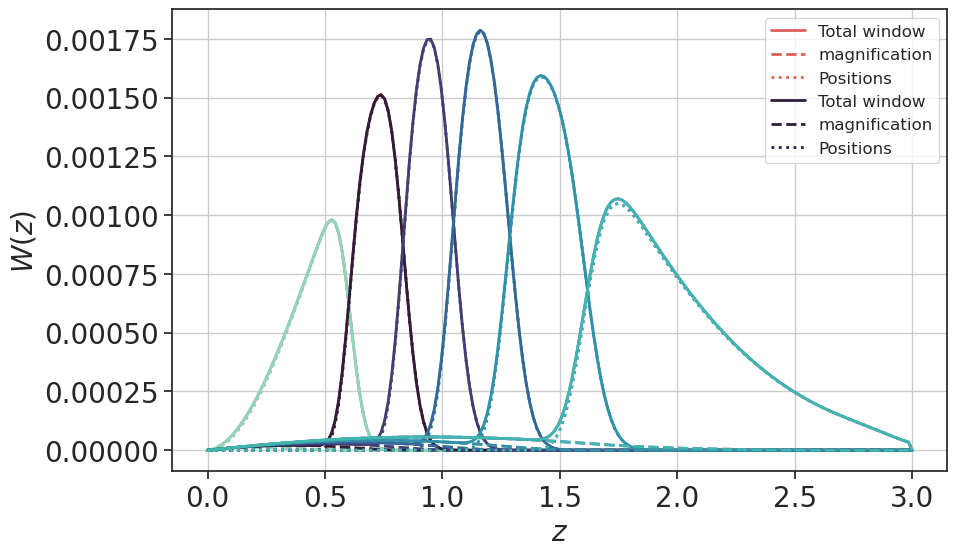

In [26]:
plt.figure(figsize=(10, 6))
Cells_standard.plot_windows_pos()
Cells_standard_nonlinear.plot_windows_pos(color_palette = 'mako')

#### Plots Cells

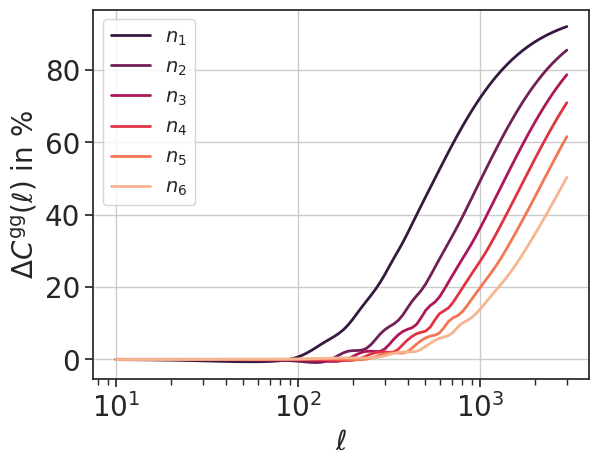

In [27]:
Cells_standard_nonlinear.plot_cells_GC_compare(Cells_standard)

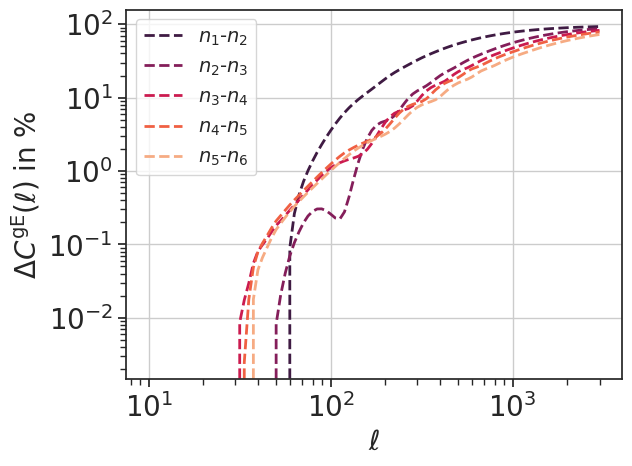

In [28]:
ij_list = [[i,i+1] for i in range(1,6)]
#Cells_standard_nonlinear.plot_cells_GGL(ij_list)
Cells_standard_nonlinear.plot_cells_GGL_compare(Cells_standard, ij_list, in_percent = True, yscale = 'log')

## Photometric 2x2pt observables: Weyl implementation of Position Tracer classes

### Observables: Weyl implementation of position tracers (CLASS, linear)

Here, we are testing the Weyl implementation of positions tracer classes (PositionsTracer_Weyl_GGL and PositionsTracer_Weyl_GC).
Specifically, we test how well they correspond to the standard implementation, both at the level of window functions and at the level of Cells.
We note that for this comparison, the values of Jhat and bhat are set to their LCDM prediction in all bins.

In [18]:
Cells_Weyl = Cells_calculation_Weyl(linear_perturbations_CLASS, 
                                    linear_perturbations_CLASS, 
                                    my_dndz_pos_norm, 
                                    my_dndz_she_norm, 
                                    zs,
                                    z_ini = z_ini, 
                                    include_rsd = False,)
Cells_Weyl.calculate_Cells()

#### Plots window functions

Window functions of the Weyl and standard implementations correspond perfectly to each other 
(applying some expected rescalings).

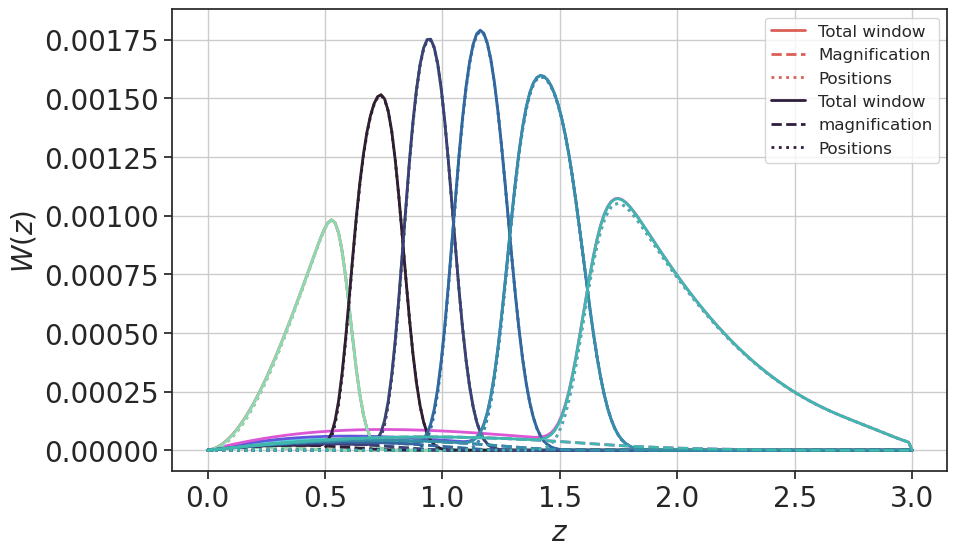

In [19]:
plt.figure(figsize=(10, 6))
Cells_Weyl.plot_windows_pos(pos_type = 'GC')
#Cells_Weyl_useWeylpert.plot_windows_pos(pos_type = 'GGL')
Cells_standard.plot_windows_pos(color_palette = 'mako')

#### Plots Cells

We see that standard and Weyl Cells correspond very well (using CLASS linear perturbations).
Differences of few percent are explained by the width of photometric bins, and the fact that the Weyl implementation treats some quantities (Jhat and bhat) as constant per bin.

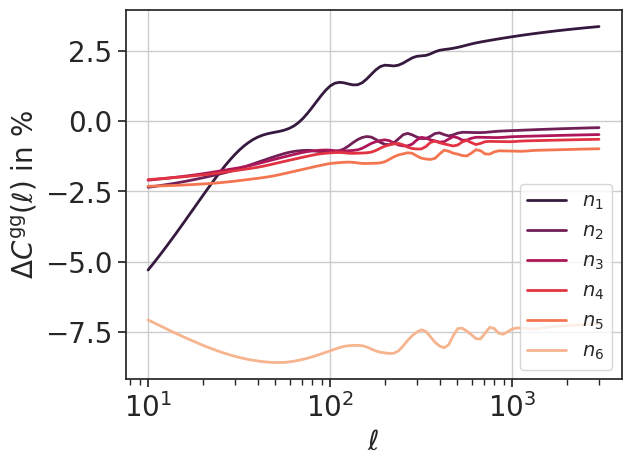

In [20]:
Cells_Weyl.plot_cells_GC_compare(Cells_standard)

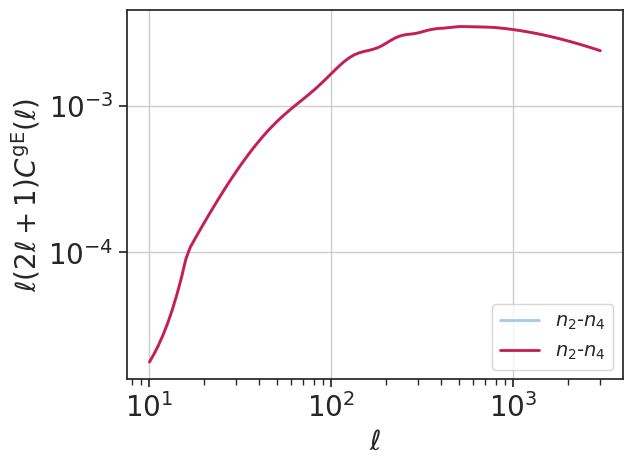

In [33]:
ij_list = [[i,i+2] for i in range(2,3)]
Cells_Weyl.plot_cells_GGL(ij_list, color_palette = 'pastel')
Cells_standard.plot_cells_GGL(ij_list)
#Cells_Weyl.plot_cells_GGL_compare(Cells_standard, ij_list, in_percent = False, yscale = 'log')

### Observables: Weyl implementation of position tracers (CAMB, linear)

We test the Weyl implementation of position tracers classes using CAMB linear perturbations. We see sub-percent differences between CAMB and CLASS at the level of the Cells (similar to the comparison between CAMB and CLASS for the standard implementation).

In [33]:
Cells_Weyl_CAMB = Cells_calculation_Weyl(linear_perturbations_CAMB,
                                         linear_perturbations_CAMB, 
                                         my_dndz_pos_norm, 
                                         my_dndz_she_norm, 
                                         zs, 
                                         z_ini = z_ini,
                                        ) 
Cells_Weyl_CAMB.calculate_Cells()

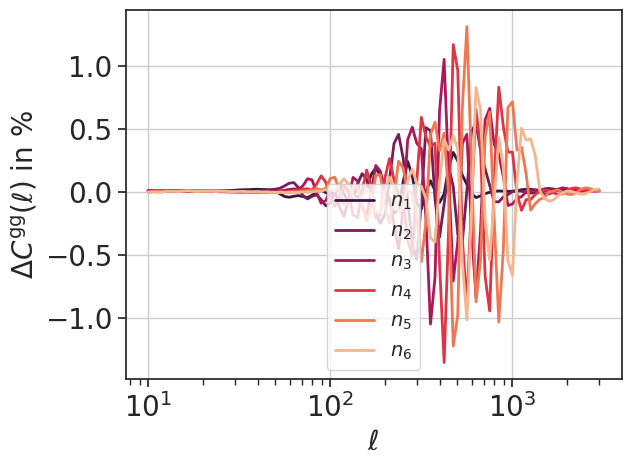

In [34]:
Cells_Weyl_CAMB.plot_cells_GC_compare(Cells_Weyl)

### Observables: Weyl implementation of position tracers (CLASS, non-linear)

Again, we check how well the standard and Weyl implementation of position tracer classes correspond to each other, now using *non-linear* CLASS perturbations. This provides a consistency check for the boost implemented in the class Weyl_Perturbations.

In [35]:
Cells_Weyl_nonlinear = Cells_calculation_Weyl(nonlinear_perturbations_CLASS, 
                                              linear_perturbations_CLASS,
                                              my_dndz_pos_norm, 
                                              my_dndz_she_norm, 
                                              zs, 
                                              z_ini = z_ini,
                                             )
Cells_Weyl_nonlinear.calculate_Cells()

#### Plots window functions

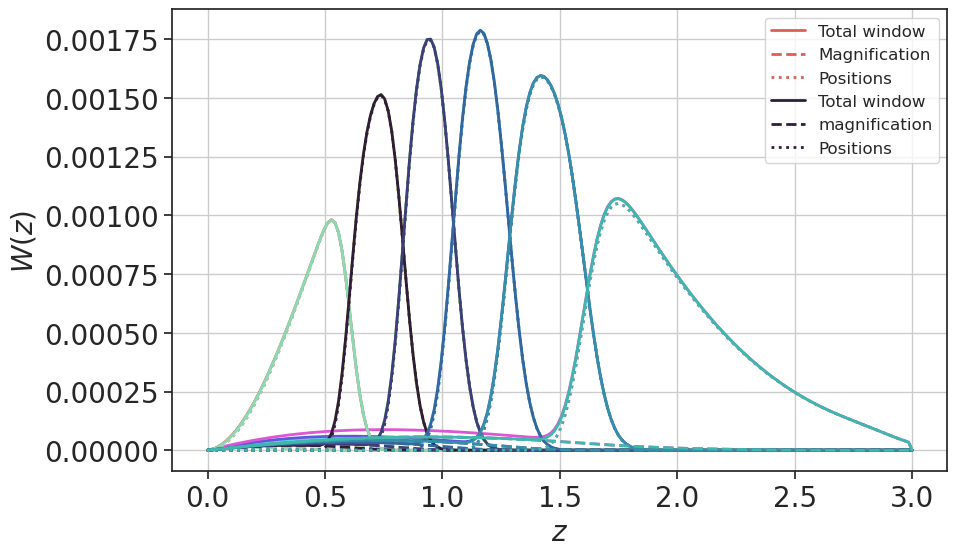

In [36]:
plt.figure(figsize=(10, 6))
Cells_Weyl_nonlinear.plot_windows_pos(pos_type = 'GC')
#Cells_Weyl_nonlinear.plot_windows_pos(pos_type = 'GGL')
Cells_standard.plot_windows_pos(color_palette = 'mako')

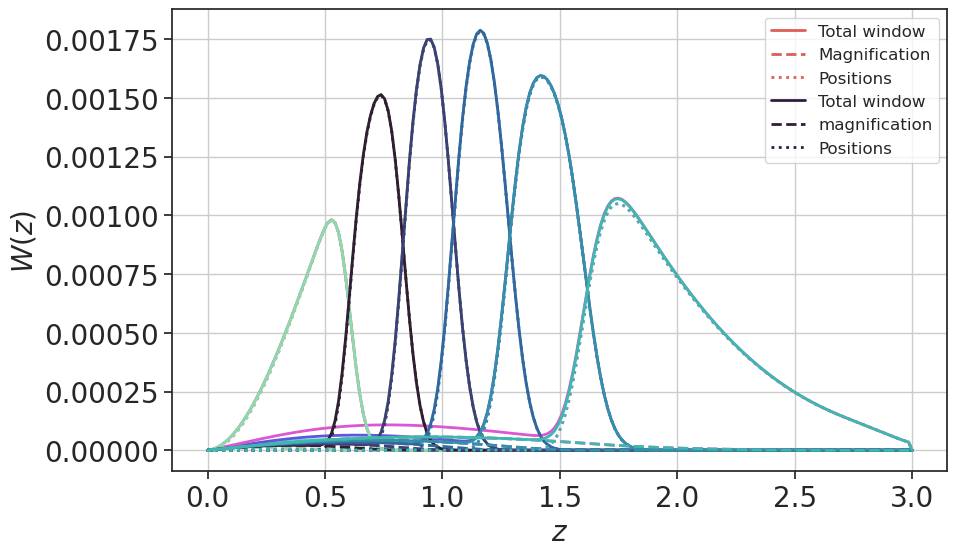

In [37]:
plt.figure(figsize=(10, 6))
#Cells_Weyl_nonlinear.plot_windows_pos(pos_type = 'GC')
Cells_Weyl_nonlinear.plot_windows_pos(pos_type = 'GGL')
Cells_standard.plot_windows_pos(color_palette = 'mako')

#### Plots Cells

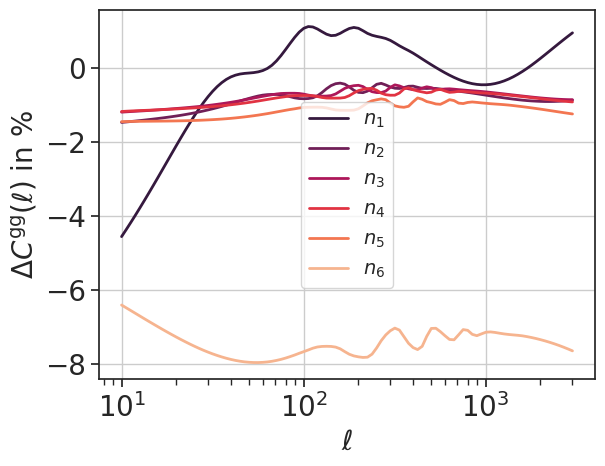

In [38]:
Cells_Weyl_nonlinear.plot_cells_GC_compare(Cells_standard_nonlinear)

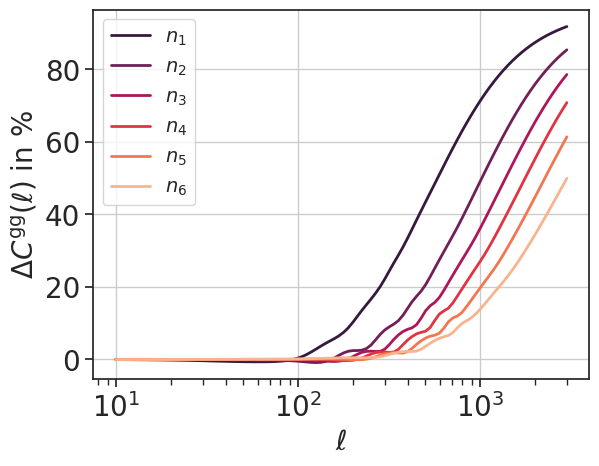

In [39]:
Cells_Weyl_nonlinear.plot_cells_GC_compare(Cells_Weyl)

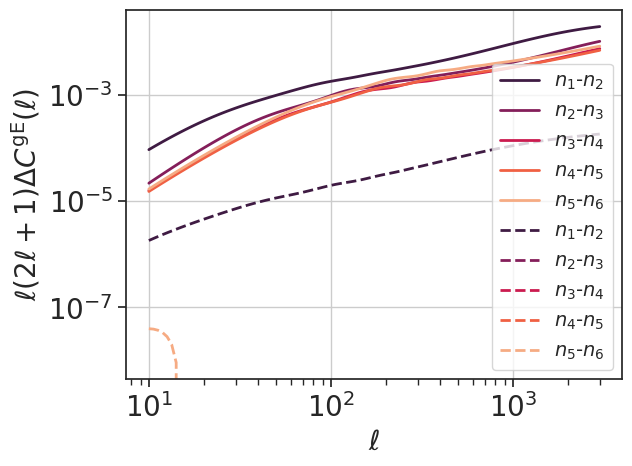

In [40]:
ij_list = [[i,i+1] for i in range(1,6)]
Cells_Weyl_nonlinear.plot_cells_GGL(ij_list)
Cells_Weyl_nonlinear.plot_cells_GGL_compare(Cells_standard_nonlinear, ij_list, in_percent = False, yscale = 'log')

### Observables: Weyl implementation of position tracers with a different z_ini (CLASS)

We check how much the calculation of the Cells, using the Weyl implementation, depends on the specific choice of z_ini (using CLASS linear and non-linear perturbations). We differences at the level of ~1% between z_ini = 10 and z_ini = 4.

In [66]:
z_ini_test = 4.00
Cells_Weyl_zini_test = Cells_calculation_Weyl(linear_perturbations_CLASS_zini_test, 
                                              linear_perturbations_CLASS_zini_test,
                                              my_dndz_pos_norm, 
                                              my_dndz_she_norm, 
                                              zs, 
                                              z_ini = z_ini_test,)
Cells_Weyl_zini_test.calculate_Cells()

In [67]:
Cells_Weyl_nonlinear_zini_test = Cells_calculation_Weyl(nonlinear_perturbations_CLASS_zini_test, 
                                                        linear_perturbations_CLASS_zini_test,
                                                        my_dndz_pos_norm, 
                                                        my_dndz_she_norm, 
                                                        zs, 
                                                        z_ini = z_ini_test,)
Cells_Weyl_nonlinear_zini_test.calculate_Cells()

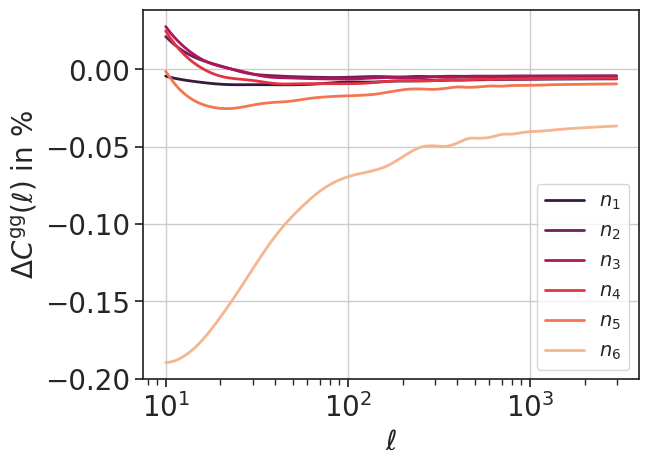

In [68]:
# old boost implementation, z_ini_test = 4, z_ini = 10
Cells_Weyl_zini_test.plot_cells_GC_compare(Cells_Weyl, in_percent = True)

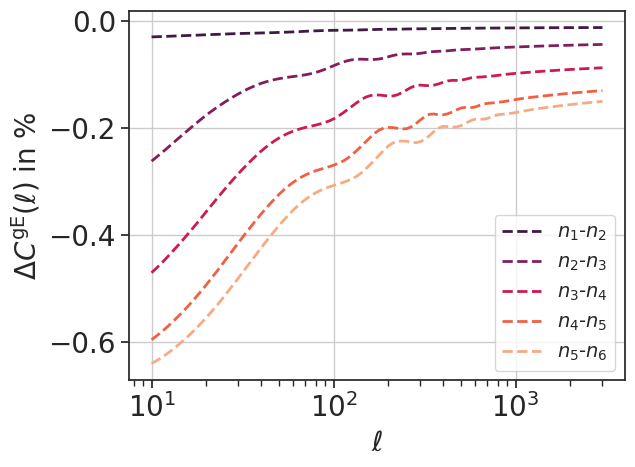

In [69]:
ij_list = [[i,i+1] for i in range(1,6)]
Cells_Weyl_zini_test.plot_cells_GGL_compare(Cells_Weyl, ij_list, in_percent = True, yscale = 'linear')

In [70]:
Cells_Weyl_nonlinear_zini_test.plot_cells_GC_compare(Cells_Weyl_nonlinear)

NameError: name 'Cells_Weyl_nonlinear' is not defined

In [71]:
ij_list = [[i,i+1] for i in range(1,6)]
Cells_Weyl_nonlinear_zini_test.plot_cells_GGL_compare(Cells_Weyl_nonlinear, ij_list, in_percent = True, yscale = 'linear')

NameError: name 'Cells_Weyl_nonlinear' is not defined

In [72]:
Cells_Weyl_zini_test.tracer_pos_GC.sigma8_ini

np.float64(0.20618342033967962)

In [48]:
Cells_Weyl.tracer_pos_GC.sigma8_ini

np.float64(0.09411332367898963)

In [49]:
def growth(z1, z0, perturbations):
    result = perturbations.growth_factor(np.array([z1]), perturbations.k[:1])[0, 0]/perturbations.growth_factor(np.array([z0]), perturbations.k[:1])[0, 0]
    return result

In [50]:
z_ini_test

4.0

In [51]:
num_growth = growth(z_ini, z_ini_test, Cells_Weyl.perturbations)

In [52]:
Cells_Weyl_zini_test.tracer_pos_GC.sigma8_ini*growth(z_ini, z_ini_test, Cells_Weyl.perturbations)

np.float64(0.09369087833332924)

### Observables: Weyl implementation of position tracers using Weyl_perturbations (with NON-LINEAR CAMB perturbations)

The Weyl implementation of positions tracer using CLASS vs. CAMB non-linear perturbations leads to sub-percent differences

In [54]:
Cells_Weyl_CAMB_nonlinear = Cells_calculation_Weyl(nonlinear_perturbations_CAMB,
                                                   linear_perturbations_CAMB,
                                                   my_dndz_pos_norm, 
                                                   my_dndz_she_norm, 
                                                   zs,  
                                                   z_ini = z_ini)
Cells_Weyl_CAMB_nonlinear.calculate_Cells()

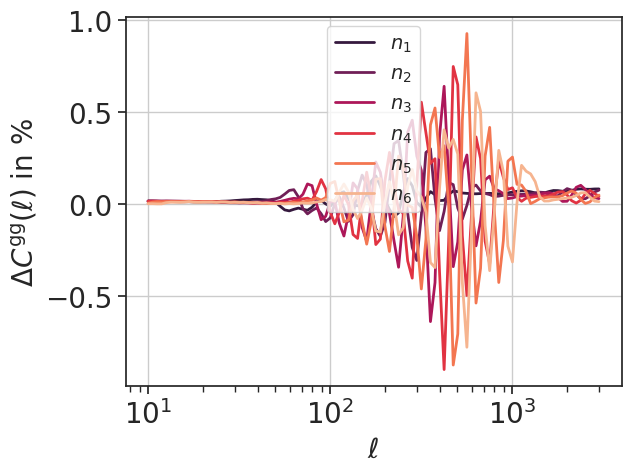

In [55]:
Cells_Weyl_CAMB_nonlinear.plot_cells_GC_compare(Cells_Weyl_nonlinear)

### Observables: Weyl implementation of position tracers using Weyl_perturbations (with linear HMCode2020emu perturbations)

In [135]:
Cells_Weyl_emu = Cells_calculation_Weyl(linear_perturbations_emu, 
                                        linear_perturbations_emu,
                                        my_dndz_pos_norm, 
                                        my_dndz_she_norm, 
                                        zs,
                                        z_ini= 4.) # only works with z_ini = 4 max. for HM emu perturbations
Cells_Weyl_emu.calculate_Cells()

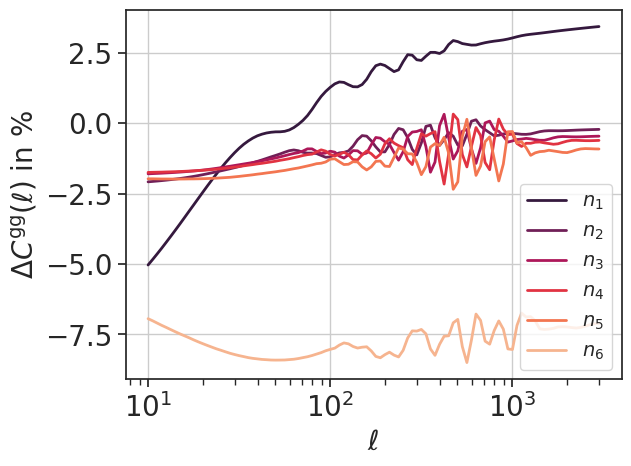

In [136]:
Cells_Weyl_emu.plot_cells_GC_compare(Cells_standard)

We want to check what happens if we sharpen the redshift distribution: Reducing the width of the bins should reduce the (already small) difference between the standard and Weyl implementations.

In [ ]:
def renormalize(dndz, zs):
    dz = np.gradient(zs)
    # dndz shape: (nbins, nz)
    norms = np.sum(dndz * dz[None, :], axis=1)  # shape (nbins,)
    # avoid divide-by-zero
    norms[norms == 0] = 1.0
    return dndz / norms[:, None]

# compute effective z and RMS sigma of each bin (using current sampling zs)
def compute_z_eff_and_sigma(dndz, zs):
    dz = np.gradient(zs)
    # dndz shape: (nbins, nz)
    z_mean = np.sum(dndz * zs[None, :] * dz[None, :], axis=1) / np.sum(dndz * dz[None, :], axis=1)
    # variance = <(z - z_mean)^2>
    var = np.sum(dndz * (zs[None, :] - z_mean[:, None])**2 * dz[None, :], axis=1) / np.sum(dndz * dz[None, :], axis=1)
    sigma = np.sqrt(var)
    return z_mean, sigma

# 1) Sharpen (narrow & peak more) by multiplicative Gaussian around z_eff
def sharpen_dndz_by_gaussian(my_dndz, zs, z_eff, sigma_current, sigma_scale=0.5):
    """
    my_dndz: array shape (nbins, nz) normalized per-bin
    zs: 1D redshift array corresponding to columns
    z_eff: array shape (nbins,) effective z for each bin
    sigma_current: array shape (nbins,) current RMS width for each bin
    sigma_scale: float <1 => narrower (sharpen); >1 => wider (but multiplicative method is mainly for sharpening)
    """
    nbins, nz = my_dndz.shape
    out = np.zeros_like(my_dndz)
    for i in range(nbins):
        sigma_new = sigma_current[i] * sigma_scale
        # if sigma_current is zero (pathological), choose a fallback small width
        if sigma_new == 0:
            sigma_new = 1e-3
            
        gauss = np.exp(-0.5 * ((zs - z_eff[i]) / sigma_new)**2)
        out[i, :] = my_dndz[i, :] * gauss
    out = renormalize(out, zs)
    return out

In [ ]:
# Example workflow using your arrays:
# my_dndz_pos_norm has shape (nbins, nz) and is already normalized over z (using zs grid)
zs_grid = zs  # the 100-point zs you resampled to

# compute current z_eff and sigma for each bin (on the resampled grid)
z_eff_resampled, sigma_resampled = compute_z_eff_and_sigma(my_dndz_pos_norm , zs_grid)

# Sharpen: make them peak more (use sigma_scale < 1, like 0.4 or 0.6)
# Note that even sigma_scale = 1.0 will change the n(z), because the original n(z) are non-Gaussian!
my_dndz_pos_sharper = sharpen_dndz_by_gaussian(my_dndz_pos_norm, zs_grid, z_eff_resampled, sigma_resampled, sigma_scale=0.2)
my_dndz_she_sharper = my_dndz_pos_sharper 

# check new effective redshifts and widths after transforms
z_eff_sharper, sigma_sharper = compute_z_eff_and_sigma(my_dndz_pos_sharper, zs_grid)

# Print a quick summary (example)
for i in range(my_dndz_pos_sharper.shape[0]):
    print(f"bin {i}: z_eff orig {z_eff_resampled[i]:.4f}, sigma orig {sigma_resampled[i]:.4f} "
          f"-> sharper sigma {sigma_sharper[i]:.4f}")

bin 0: z_eff orig 0.4371, sigma orig 0.1303 -> sharper sigma 0.0259
bin 1: z_eff orig 0.7260, sigma orig 0.0835 -> sharper sigma 0.0165
bin 2: z_eff orig 0.9424, sigma orig 0.0845 -> sharper sigma 0.0167
bin 3: z_eff orig 1.1640, sigma orig 0.0940 -> sharper sigma 0.0186
bin 4: z_eff orig 1.4370, sigma orig 0.1184 -> sharper sigma 0.0235
bin 5: z_eff orig 1.9634, sigma orig 0.3018 -> sharper sigma 0.0602


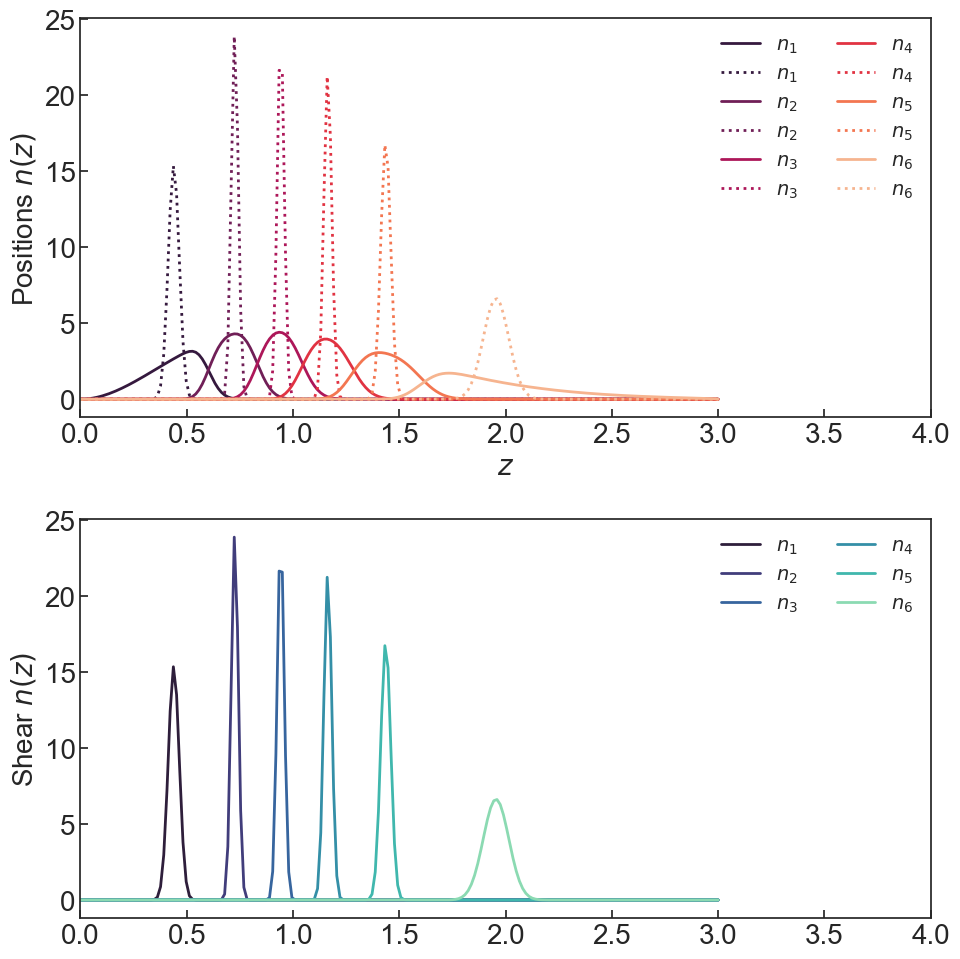

In [ ]:
# Plotting dndz
fig, axs = plt.subplots(2, 1, figsize=(10, 10))

# Customize tick parameters for both axes
for ax in axs.flatten():
    ax.tick_params(axis='both', which='both', direction='in')

# Plot positions n(z)
for i in range(6):
    color = sns.color_palette("rocket",6)[i]
    axs[0].plot(zs, my_dndz_pos_norm[i], label=f'$n_{{{i+1}}}$', linewidth=2, color=color)
    axs[0].plot(zs, my_dndz_pos_sharper[i], linestyle=':', label=f'$n_{{{i+1}}}$', linewidth=2, color=color)

#for i, (key, color) in enumerate(zip(dndz_pos_norm.keys(), sns.color_palette("rocket", len(dndz_pos_norm)))):
#    axs[0].plot(z_nz, my_dndz_pos_norm[key], label=f'$n_{{{i+1}}}$', linewidth=2, color=color)

# Plot shear n(z)
for j, (key, color) in enumerate(zip(dndz_she_norm.keys(), sns.color_palette("mako", len(my_dndz_she_norm)))):
    axs[1].plot(zs, my_dndz_she_sharper[j], label=f'$n_{{{j+1}}}$', linewidth=2, color=color)

# Set labels and legends
axs[0].set_xlabel(r'$z$')
axs[0].set_ylabel(r'Positions $n(z)$')
axs[0].set_xlim(0, 4)
axs[0].legend(frameon=False, ncol=2)

#axs[1].set_xlabel(r'$z$')
axs[1].set_ylabel(r'Shear $n(z)$')
axs[1].set_xlim(0, 4)
axs[1].legend(frameon=False, ncol=2)

plt.tight_layout()
plt.show()

In [ ]:
Cells_standard_sharper = Cells_calculation(linear_perturbations_CLASS, 
                                           my_dndz_pos_sharper, 
                                           my_dndz_she_sharper, 
                                           zs)
Cells_standard_sharper.calculate_Cells()

Cells_Weyl_sharper = Cells_calculation_Weyl(linear_perturbations_CLASS, 
                                            linear_perturbations_CLASS,
                                            my_dndz_pos_sharper, 
                                            my_dndz_she_sharper, 
                                            zs,
                                            z_ini = z_ini)
Cells_Weyl_sharper.calculate_Cells()

Cells_Weyl_sharper_zini_test = Cells_calculation_Weyl(linear_perturbations_CLASS_zini_test, 
                                                      linear_perturbations_CLASS_zini_test,
                                                      my_dndz_pos_sharper, 
                                                      my_dndz_she_sharper, 
                                                      zs, 
                                                      z_ini = z_ini_test)
Cells_Weyl_sharper_zini_test.calculate_Cells()

Cells_standard_sharper_CAMB = Cells_calculation(linear_perturbations_CAMB, my_dndz_pos_sharper, my_dndz_she_sharper, zs)
Cells_standard_sharper_CAMB.calculate_Cells()
#Cells_Weyl_sharper_CAMB = Cells_calculation_Weyl(linear_perturbations_CAMB_Weyl, my_dndz_pos_sharper, my_dndz_she_sharper, zs, use_Weyl_perturbations = True, z_ini = z_ini)
#Cells_Weyl_sharper_CAMB.calculate_Cells()

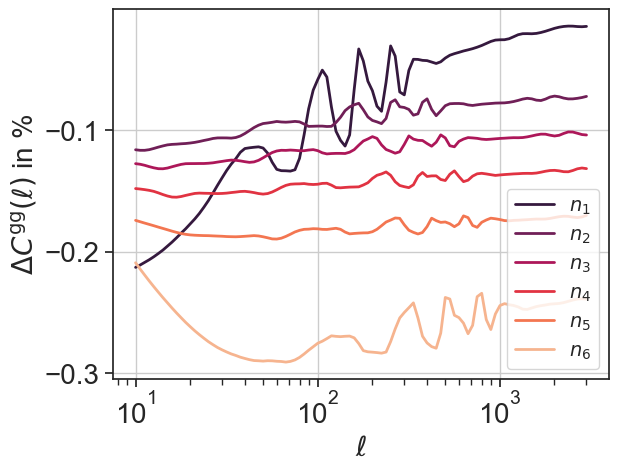

In [ ]:
Cells_Weyl_sharper.plot_cells_GC_compare(Cells_standard_sharper)

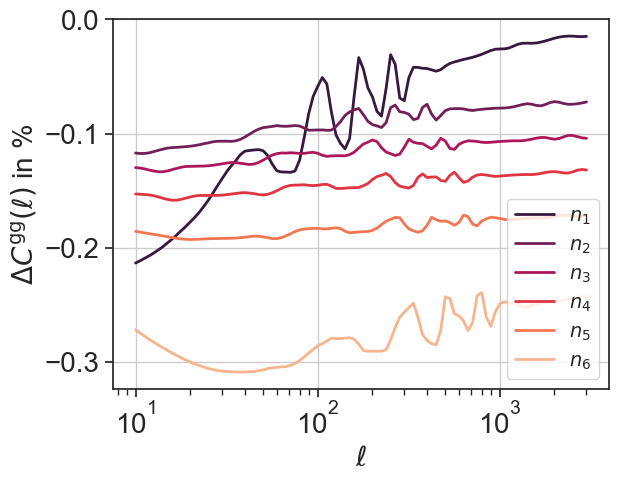

In [ ]:
Cells_Weyl_sharper_zini_test.plot_cells_GC_compare(Cells_standard_sharper)

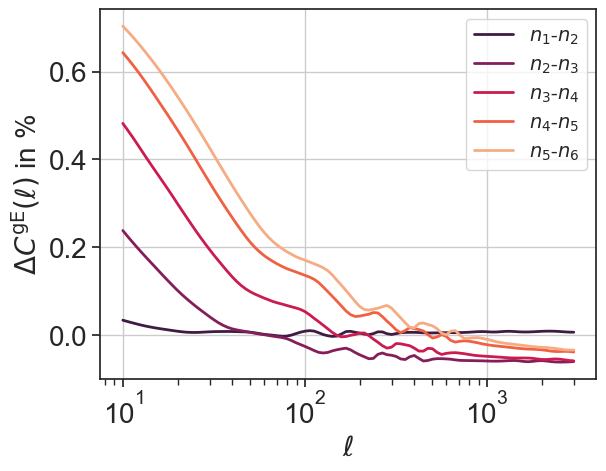

In [ ]:
ij_list = [[i,i+1] for i in range(1,6)]
Cells_Weyl_sharper.plot_cells_GGL_compare(Cells_standard_sharper, ij_list, in_percent = True, yscale = 'linear', linestyle = '-')

## Check implementation of RSD effect

In [ ]:
Cells_standard_rsd = Cells_calculation(linear_perturbations_CLASS, my_dndz_pos_norm, my_dndz_she_norm, zs, include_rsd = True)
Cells_standard_rsd.calculate_Cells()

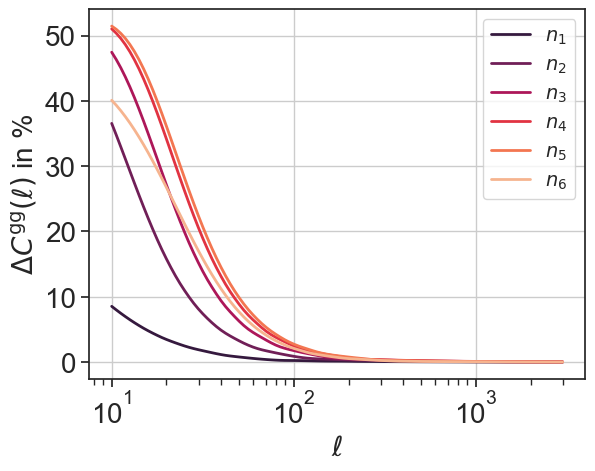

In [ ]:
Cells_standard_rsd.plot_cells_GC_compare(Cells_standard)

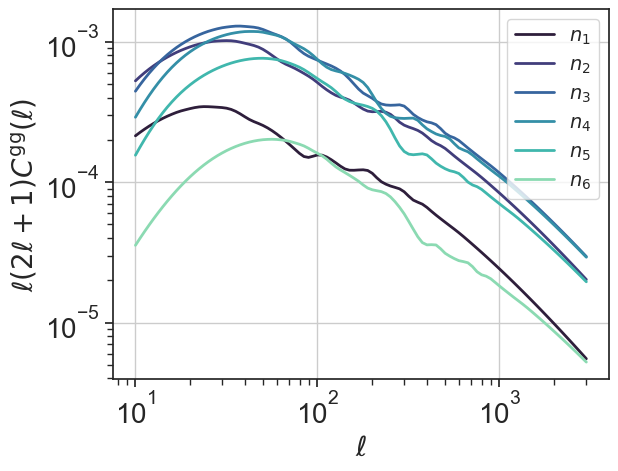

In [ ]:
ax = plt.gca()
ells = Cells_standard_rsd.ells
for i in range(0, 6):
    plt.loglog(ells, ells*(2*ells+1)*(Cells_standard_rsd.cells['POS', 'POS', i+1, i+1][:]-Cells_standard.cells['POS', 'POS', i+1, i+1][:]), label = '$n_{{{}}}$'.format(i+1), 
                       linewidth=2, color=sns.color_palette('mako', 6)[i])
ax.set_xlabel(r'$\ell$')
ax.set_ylabel(r'$\ell (2\ell +1)C^{\rm gg}(\ell)$')
ax.legend(fontsize=14)
ax.grid(True)

In [ ]:
Cells_Weyl_rsd = Cells_calculation_Weyl(linear_perturbations_CLASS, 
                                        linear_perturbations_CLASS, 
                                        my_dndz_pos_norm, 
                                        my_dndz_she_norm, 
                                        zs, 
                                        z_ini = z_ini, 
                                        include_rsd = True)
Cells_Weyl_rsd.calculate_Cells()

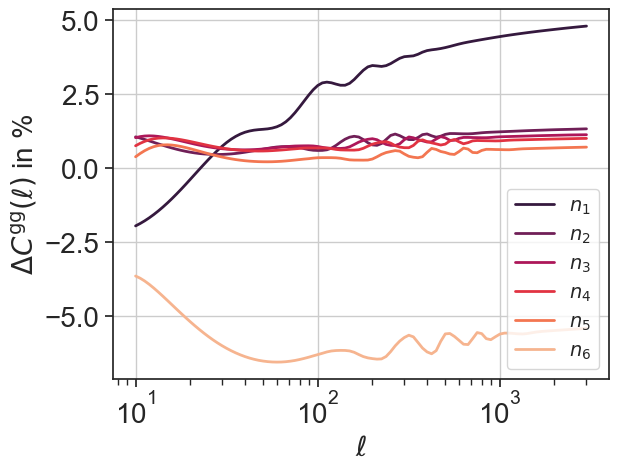

In [ ]:
Cells_Weyl_rsd.plot_cells_GC_compare(Cells_standard_rsd)